# Recovering Young's modulus from measured extension

### A differentiable finite-element exercise with **PhAST**

*UKACM Autumn School 2026 · CEMS Lab, City St George's, University of London*

---
**Learning objective.** Build a 1D bar model, calculate its extension, and recover Young’s modulus by differentiating through the PhAST forward solve.

The notebook saves its figures, animation and numerical tables in `bar_results/` in the working directory.

## 1. Load PhAST and tools


In [1]:
import importlib.util
import subprocess
import sys

PHAST_SPEC = "phast @ git+https://github.com/CEMS-Lab/PhAST.git@157412953099bfcace1668bb35cb911826a4e95e"
if sys.version_info[:2] < (3, 10):
    raise RuntimeError("PhAST requires Python 3.10 or newer.")
if importlib.util.find_spec("phast") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", PHAST_SPEC])
import phast
if not all(hasattr(phast, name) for name in ("line_mesh", "solve_bar")):
    raise RuntimeError(f"Install with %pip install '{PHAST_SPEC}', then restart the kernel.")
print("Forward solver:", phast.solve_bar.__module__)

Forward solver: phast.bar


In [2]:
from pathlib import Path
from time import perf_counter
import json
import csv
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Image

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
lesson_start = perf_counter()
output = Path("bar_results")
output.mkdir(exist_ok=True)
plt.rcParams.update({
    "font.family": "STIXGeneral", "mathtext.fontset": "stix",
    "font.size": 13, "axes.titlesize": 16, "axes.labelsize": 14,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "svg.fonttype": "path",
})

def show_figure(fig, name):
    fig.savefig(output / f"{name}.png", dpi=180, bbox_inches="tight")
    fig.savefig(output / f"{name}.svg", bbox_inches="tight")
    display(Image(filename=str(output / f"{name}.png"), width=950))
    plt.close(fig)

## 2. Geometry and material setup

The bar has length $L=100\,\mathrm{mm}$ and area $A=10\,\mathrm{mm}^2$.

For the reference forward calculation we choose $E_{\mathrm{ref}}=210000\,\mathrm{MPa}=210\,\mathrm{GPa}$.

We will use its tip displacement as a synthetic measurement.

The inverse loop receives that measurement and a starting guess; it does not use the reference modulus to choose updates.

$$\varepsilon=\frac{du}{dx},\qquad \sigma=E\varepsilon,\qquad N=A\sigma.$$

Here $u$ is displacement, $\varepsilon$ strain, $\sigma$ stress and $N$ internal axial force. With mm–N units, $1\,\mathrm{MPa}=1\,\mathrm{N/mm}^2$.

In [3]:
length = 100.0                       # mm
area = 10.0                          # mm^2
E_reference = torch.tensor(210000.0)  # MPa; generates the synthetic observation
print(f"Length: {length:g} mm; area: {area:g} mm²")
print(f"Reference modulus: {E_reference.item()/1000:g} GPa")

Length: 100 mm; area: 10 mm²
Reference modulus: 210 GPa


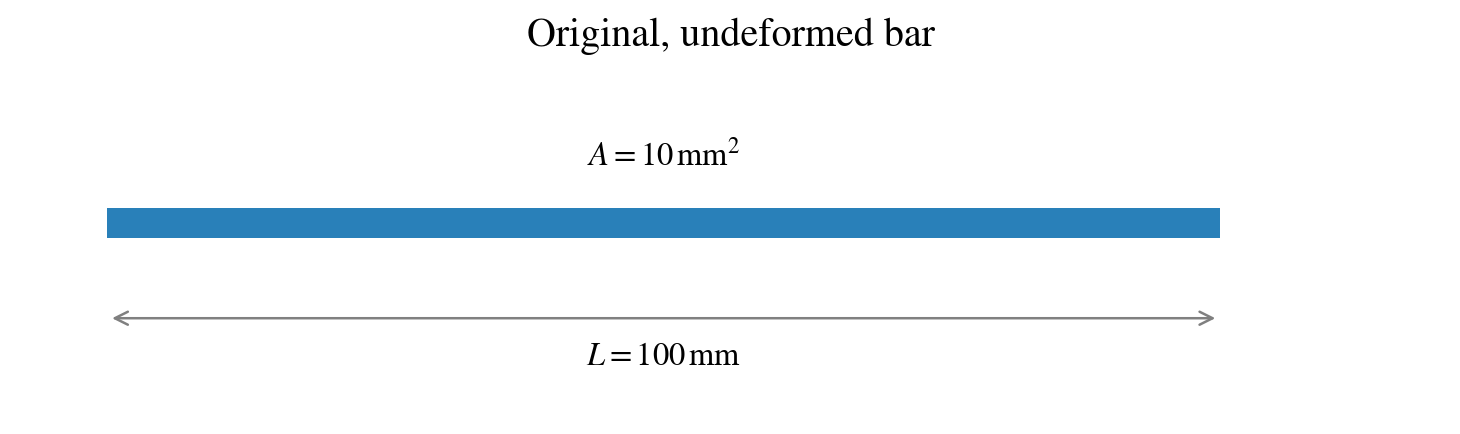

In [4]:
fig, ax = plt.subplots(figsize=(8, 2.3), layout="constrained")
ax.plot([0, length], [0, 0], lw=12, color="#2980B9", solid_capstyle="butt")
ax.annotate("", (length, -0.32), (0, -0.32), arrowprops={"arrowstyle": "<->", "color": "gray"})
ax.text(length/2, -0.4, r"$L=100\,\mathrm{mm}$", ha="center", va="top")
ax.text(length/2, 0.2, r"$A=10\,\mathrm{mm}^2$", ha="center")
ax.set(xlim=(-8, 120), ylim=(-.65, .55), title="Original, undeformed bar")
ax.axis("off")
show_figure(fig, "01_geometry")

## 3. Generate the line mesh
PhAST creates **10 two-node axial elements and 11 nodes**. Each node has one axial displacement.

Within an element of length $h$, displacement varies linearly. PhAST assembles the element stiffness

$$\mathbf K_e=\frac{EA}{h}\begin{bmatrix}1&-1\\-1&1\end{bmatrix}.$$

In [5]:
mesh = phast.line_mesh(length=length, n_elements=10)
x = mesh.nodes.detach().numpy()
print("Coordinates [mm]:", mesh.nodes.tolist())
print("Element connectivity:")
print(mesh.elements)

Coordinates [mm]: [0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0]
Element connectivity:
tensor([[ 0,  1],
        [ 1,  2],
        [ 2,  3],
        [ 3,  4],
        [ 4,  5],
        [ 5,  6],
        [ 6,  7],
        [ 7,  8],
        [ 8,  9],
        [ 9, 10]])


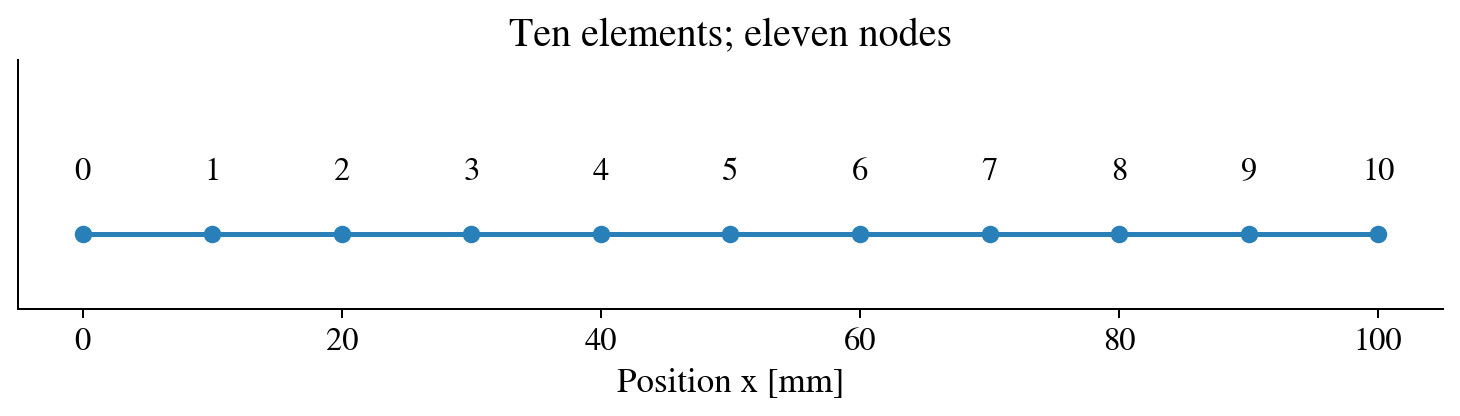

In [6]:
fig, ax = plt.subplots(figsize=(8, 2.2), layout="constrained")
ax.plot(x, np.zeros_like(x), "o-", color="#2980B9", lw=2)
for node, position in enumerate(x):
    ax.text(position, .09, str(node), ha="center")
ax.set(xlim=(-5, 105), ylim=(-.12, .28), xlabel="Position x [mm]",
       title="Ten elements; eleven nodes", yticks=[])
show_figure(fig, "02_mesh")

## 4. Boundary conditions and load

Fix the left end and apply a force of $F=4000\,\mathrm N$ at the right end,
directed along positive $x$:

$$u(0)=0,\qquad EA\frac{du}{dx}\bigg|_{x=L}=F.$$


In [7]:
left_displacement = 0.0  # mm
force = 4000.0            # N; held fixed in every forward evaluation

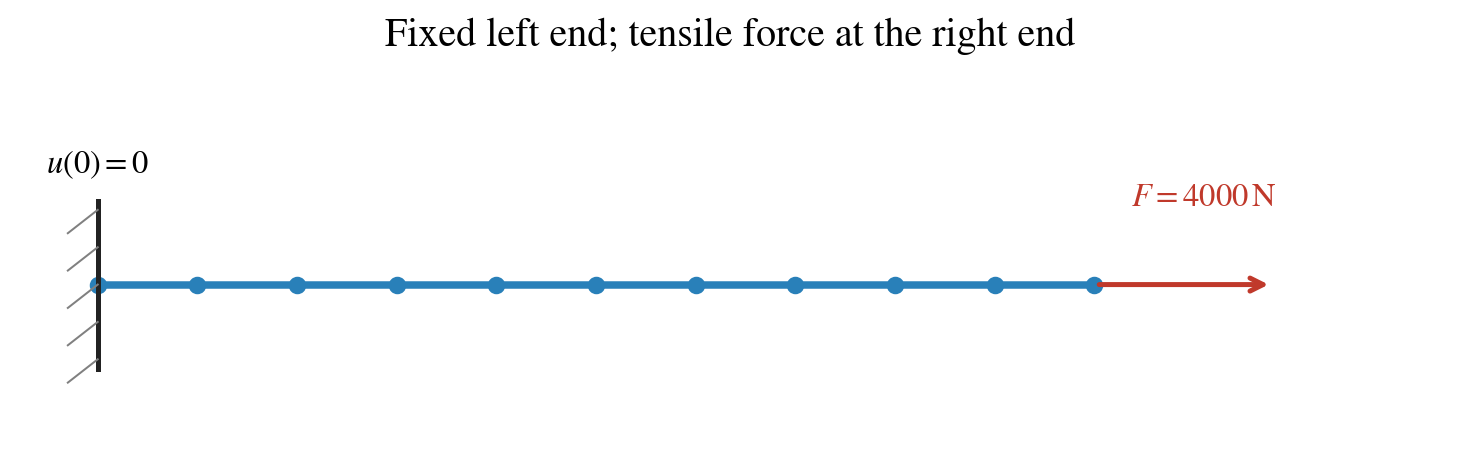

In [8]:
fig, ax = plt.subplots(figsize=(8, 2.4), layout="constrained")
ax.plot(x, np.zeros_like(x), "o-", color="#2980B9", lw=3)
ax.plot([0, 0], [-.18, .18], color="#222222", lw=2)
for y in np.linspace(-.16, .16, 5):
    ax.plot([-3, 0], [y-.05, y], color="gray", lw=.8)
ax.annotate("", (118, 0), (100, 0), arrowprops={"arrowstyle": "->", "color": "#C0392B", "lw": 2})
ax.text(111, .17, r"$F=4000\,\mathrm{N}$", ha="center", color="#C0392B")
ax.text(0, .24, r"$u(0)=0$", ha="center")
ax.set(xlim=(-8, 135), ylim=(-.32, .48), title="Fixed left end; tensile force at the right end")
ax.axis("off")
show_figure(fig, "03_boundary_force")

## 5. Write the forward function

PhAST assembles the axial stiffness matrix and solves equilibrium for the free
displacement degrees of freedom:

$$\mathbf K_{ff}(E)\mathbf u_f=\mathbf f_f.$$

The subscript $f$ identifies the unconstrained degrees of freedom. The fixed
left-end displacement is zero. This example uses PhAST's differentiable sparse
solve with a SciPy SuperLU CPU backend.

Returning tensors preserves the connection between $E$ and the displacements
for autograd.


In [9]:
def forward(E):
    return phast.solve_bar(
        mesh,
        young_modulus=E,
        area=area,
        end_force=force,
        left_displacement=left_displacement,
    )

reference = forward(E_reference)
u_reference = reference.displacement.detach()
print(f"Tip displacement: {u_reference[-1].item():.6f} mm")
print(f"Support reaction: {reference.reaction.item():.1f} N")
print(f"Maximum free-node residual: {reference.free_residual.abs().max().item():.3e} N")



Tip displacement: 0.190476 mm
Support reaction: -4000.0 N
Maximum free-node residual: 1.091e-11 N


/usr/local/lib/python3.13/dist-packages/phast/bar.py:88: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  K = torch.sparse_coo_tensor(indices, values, (n, n)).coalesce()


## 6. Record and visualise the forward solution
The displacement increases linearly from the fixed end to the loaded end. Strain and stress are uniform. For this bar, the independent analytical solution is

$$u(x)=\frac{Fx}{EA},\qquad u(L)=0.190476\,\mathrm{mm}.$$

We can use this analytical formula to check PhAST's output.

In [10]:
print("Node    x [mm]       u [mm]")
for node, (position, displacement) in enumerate(zip(x, u_reference)):
    print(f"{node:4d}    {position:6.1f}    {displacement.item():.8f}")

with (output / "forward_nodes.csv").open("w", newline="") as stream:
    writer = csv.writer(stream)
    writer.writerow(["node", "x_mm", "u_mm"])
    writer.writerows((i, float(xi), float(ui)) for i, (xi, ui) in enumerate(zip(x, u_reference)))

Node    x [mm]       u [mm]
   0       0.0    0.00000000
   1      10.0    0.01904762
   2      20.0    0.03809524
   3      30.0    0.05714286
   4      40.0    0.07619048
   5      50.0    0.09523810
   6      60.0    0.11428571
   7      70.0    0.13333333
   8      80.0    0.15238095
   9      90.0    0.17142857
  10     100.0    0.19047619


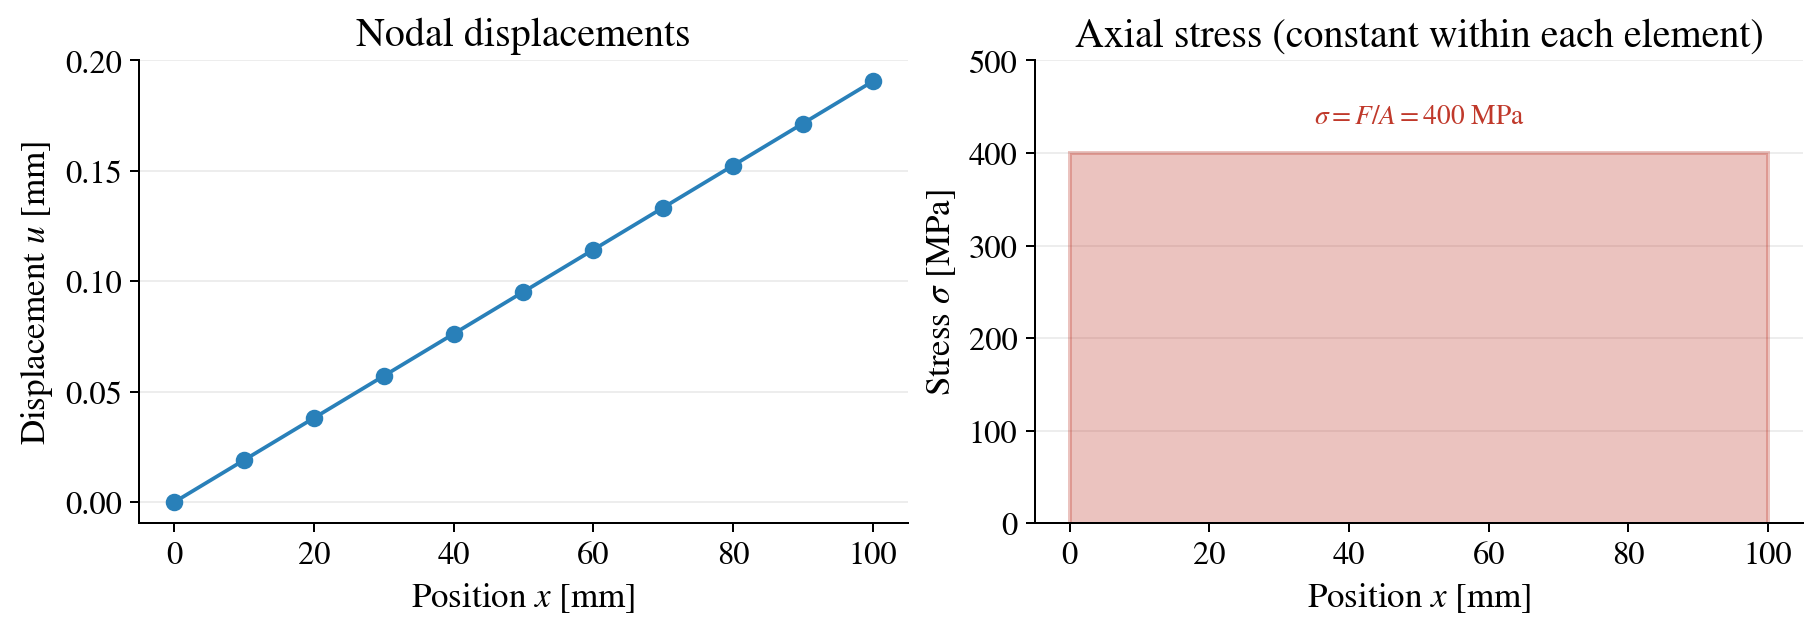

In [11]:
stress = reference.stress.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), layout="constrained")

axes[0].plot(x, u_reference.numpy(), "o-", color="#2980B9")
axes[0].set(xlabel="Position $x$ [mm]", ylabel="Displacement $u$ [mm]",
            title="Nodal displacements", xlim=(-5, 105))

axes[1].stairs(stress, x, baseline=0, fill=True, fc="#C0392B", alpha=0.30, ec="#C0392B", lw=1.6)
axes[1].ticklabel_format(axis="y", style="plain", useOffset=False)
axes[1].set(xlabel="Position $x$ [mm]", ylabel=r"Stress $\sigma$ [MPa]",
            title="Axial stress (constant within each element)",
            xlim=(-5, 105), ylim=(0, 1.25 * stress.max()))
axes[1].annotate(rf"$\sigma = F/A = {stress[0]:.0f}$ MPa",
                 xy=(50, stress[0]), xytext=(0, 12), textcoords="offset points",
                 ha="center", color="#C0392B", fontsize=11)

for ax in axes:
    ax.grid(axis="y", color="#E8E8E8", lw=.6)
    ax.set_axisbelow(True)

show_figure(fig, "04_forward_fields")

### See the actual extension

The plotted displacement is magnified **40 times** so the extension is visible.

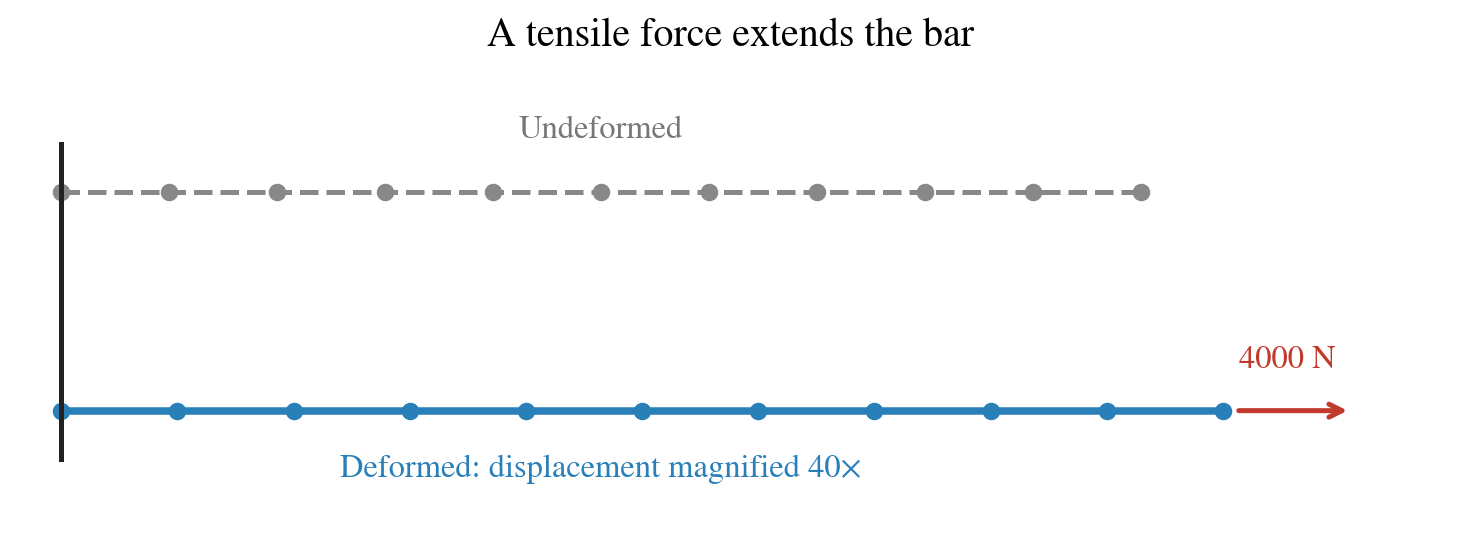

In [12]:
magnification = 40
deformed_x = x + magnification * u_reference.numpy()
fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
ax.plot(x, np.ones_like(x), "o--", color="#888888", lw=2)
ax.plot(deformed_x, np.zeros_like(x), "o-", color="#2980B9", lw=3)
ax.plot([0, 0], [-.22, 1.22], color="#222222", lw=2)
ax.annotate("", (deformed_x[-1]+12, 0), (deformed_x[-1]+1, 0),
            arrowprops={"arrowstyle":"->", "color":"#C0392B", "lw":2})
ax.text(50, 1.25, "Undeformed", ha="center", color="#777777")
ax.text(50, -.3, "Deformed: displacement magnified 40×", ha="center", color="#2980B9")
ax.text(deformed_x[-1]+6, .2, "4000 N", ha="center", color="#C0392B")
ax.set(xlim=(-4,128), ylim=(-.6,1.6), title="A tensile force extends the bar")
ax.axis("off")
show_figure(fig, "09_deformed_bar")

### Strain and stored elastic energy
The axial strain is uniform because this uniform bar carries the same axial force everywhere. Each equal-length element stores the same elastic energy:

$$\varepsilon_e=\frac{u_{e+1}-u_e}{h_e},\qquad
U_e=\frac12 E\varepsilon_e^2 A h_e.$$

The plots below are computed from the **same forward solve**, with force fixed at 4000 N.

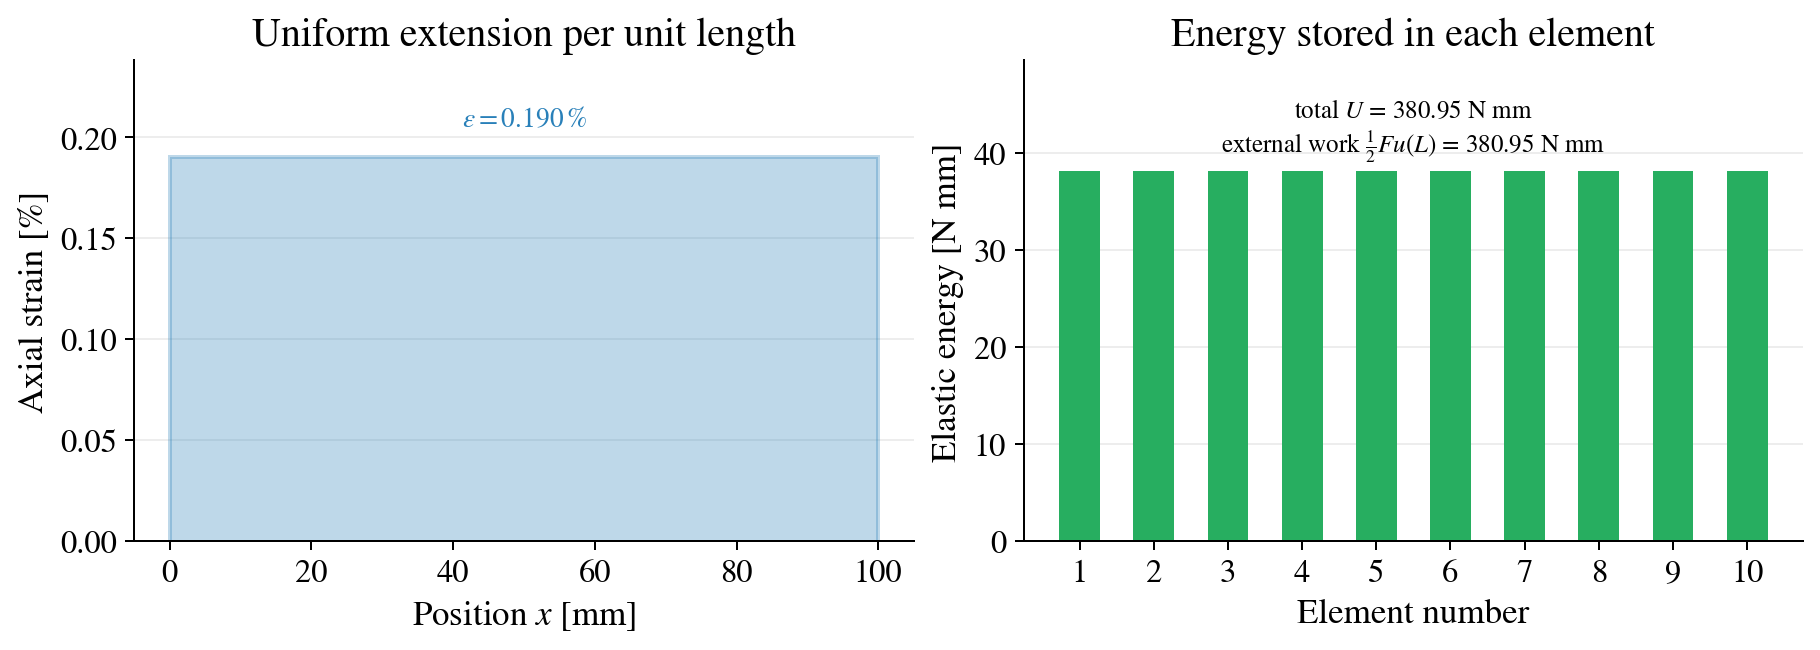

In [13]:
strain = reference.strain.detach().numpy()
stress = reference.stress.detach().numpy()
lengths = mesh.element_lengths.numpy()

# Strain energy per element:  U_e = 1/2 * sigma * eps * A * h
element_energy = 0.5 * stress * strain * area * lengths
total_energy = element_energy.sum()
external_work = 0.5 * force * reference.displacement[-1].item()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")

axes[0].stairs(strain * 100, x, baseline=0, fill=True, fc="#2980B9", alpha=0.30, ec="#2980B9", lw=1.6)
axes[0].ticklabel_format(axis="y", style="plain", useOffset=False)
axes[0].set(xlabel="Position $x$ [mm]", ylabel="Axial strain [%]",
            title="Uniform extension per unit length",
            xlim=(-5, 105), ylim=(0, 1.25 * (strain * 100).max()))
axes[0].annotate(rf"$\varepsilon = {strain[0]*100:.3f}\,\%$",
                 xy=(50, strain[0] * 100), xytext=(0, 12), textcoords="offset points",
                 ha="center", color="#2980B9", fontsize=11)

axes[1].bar(np.arange(1, len(element_energy) + 1), element_energy, width=.55, color="#27AE60")
axes[1].set(xlabel="Element number", ylabel="Elastic energy [N mm]",
            title="Energy stored in each element",
            xticks=np.arange(1, len(element_energy) + 1),
            ylim=(0, 1.3 * element_energy.max()))
axes[1].annotate(f"total $U$ = {total_energy:.2f} N mm\n"
                 rf"external work $\frac{{1}}{{2}}Fu(L)$ = {external_work:.2f} N mm",
                 xy=(0.5, 0.92), xycoords="axes fraction", ha="center", va="top", fontsize=10)

for ax in axes:
    ax.grid(axis="y", color="#E8E8E8", lw=.6)
    ax.set_axisbelow(True)

show_figure(fig, "10_strain_energy")

## 7. Define the observation and inverse question
We retain **one scalar observation**, the tip displacement from the reference solve.

Detaching it treats it as a fixed measurement during differentiation.

### Inverse question

Estimate Young’s modulus $E$ from the given extension and load.


Start from $E_0=100\,\mathrm{GPa}$.

This softer trial bar extends too much.

$$y(E)=u(L;E) $$

$$ r(E)=y(E)-y^{\mathrm{obs}},\qquad $$

$$ L(E)=\left(\frac{r(E)}{y^{\mathrm{obs}}}\right)^2.$$

The dimensionless loss is the squared relative displacement mismatch.

Zero loss means the predicted and observed tip displacements coincide.

In [14]:
observed = u_reference[-1].clone()
E_initial = torch.tensor(100000.0)

def loss_from_tip(tip):
    return ((tip - observed) / observed).square()

initial = forward(E_initial)
print(f"Observed tip: {observed.item():.6f} mm")
print(f"Initial tip:  {initial.displacement[-1].item():.6f} mm")
print(f"Initial loss: {loss_from_tip(initial.displacement[-1]).item():.6f}")

Observed tip: 0.190476 mm
Initial tip:  0.400000 mm
Initial loss: 1.210000


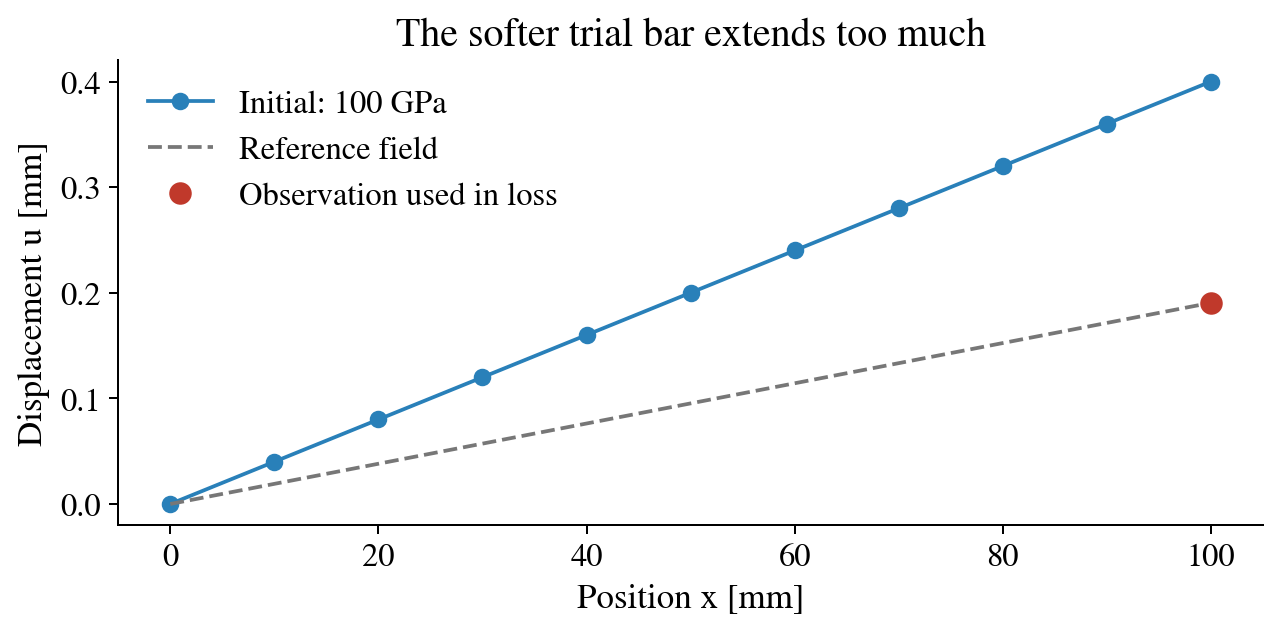

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
ax.plot(x, initial.displacement.detach().numpy(), "o-", color="#2980B9", label="Initial: 100 GPa")
ax.plot(x, u_reference.numpy(), "--", color="#777777", label="Reference field")
ax.plot([length], [observed.item()], "o", color="#C0392B", ms=8, label="Observation used in loss")
ax.set(xlabel="Position x [mm]", ylabel="Displacement u [mm]", title="The softer trial bar extends too much")
ax.legend(frameon=False)
show_figure(fig, "05_initial_prediction")

## 8. Differentiate through the PhAST solve

Set `requires_grad=True` on $E$ to record supported tensor operations for
autograd. PhAST's sparse solve supplies a custom backward rule for the solution
of the linear system. Together, these operations connect the modulus to the
scalar displacement loss $\mathcal L$:

$$
E \longrightarrow \mathbf K_{ff}(E) \longrightarrow \mathbf u_f(E)
\longrightarrow y(E) \longrightarrow \mathcal L(E).
$$

Here $f$ identifies the free displacement degrees of freedom and $y=u(L)$ is
the tip extension. At fixed force, differentiating equilibrium gives the
displacement sensitivity:

$$
\mathbf K_{ff}\frac{\partial\mathbf u_f}{\partial E}
=-\frac{\partial\mathbf K_{ff}}{\partial E}\mathbf u_f.
$$

For a scalar loss, reverse-mode differentiation expresses the gradient using an
adjoint vector $\boldsymbol\lambda$. It solves a transposed linear system and
then combines the adjoint with the stiffness sensitivity:

$$
\mathbf K_{ff}^{T}\boldsymbol\lambda
=\frac{\partial\mathcal L}{\partial\mathbf u_f},
\qquad
\frac{d\mathcal L}{dE}
=-\boldsymbol\lambda^{T}
\frac{\partial\mathbf K_{ff}}{\partial E}\mathbf u_f.
$$

The right-hand side measures how the loss changes with displacement. This
backward relation propagates that sensitivity to $E$ through the equilibrium
solve.

### The same derivative by hand

For this uniform bar, the analytical tip displacement is $y=FL/(EA)$.
The chain rule gives an independent check of the gradient:

$$
\frac{d\mathcal L}{dE}
=\frac{d\mathcal L}{dy}\frac{dy}{dE}
=\frac{2(y-y^{\mathrm{obs}})}{(y^{\mathrm{obs}})^2}
\left(-\frac{y}{E}\right).
$$

The first factor differentiates the loss while holding the observation fixed.
The second factor describes the mechanics: increasing $E$ reduces the bar's
extension. At the initial guess, $dy/dE<0$ and $d\mathcal L/dy>0$, so
$d\mathcal L/dE<0$. Increasing the modulus brings the predicted extension
closer to the observation.


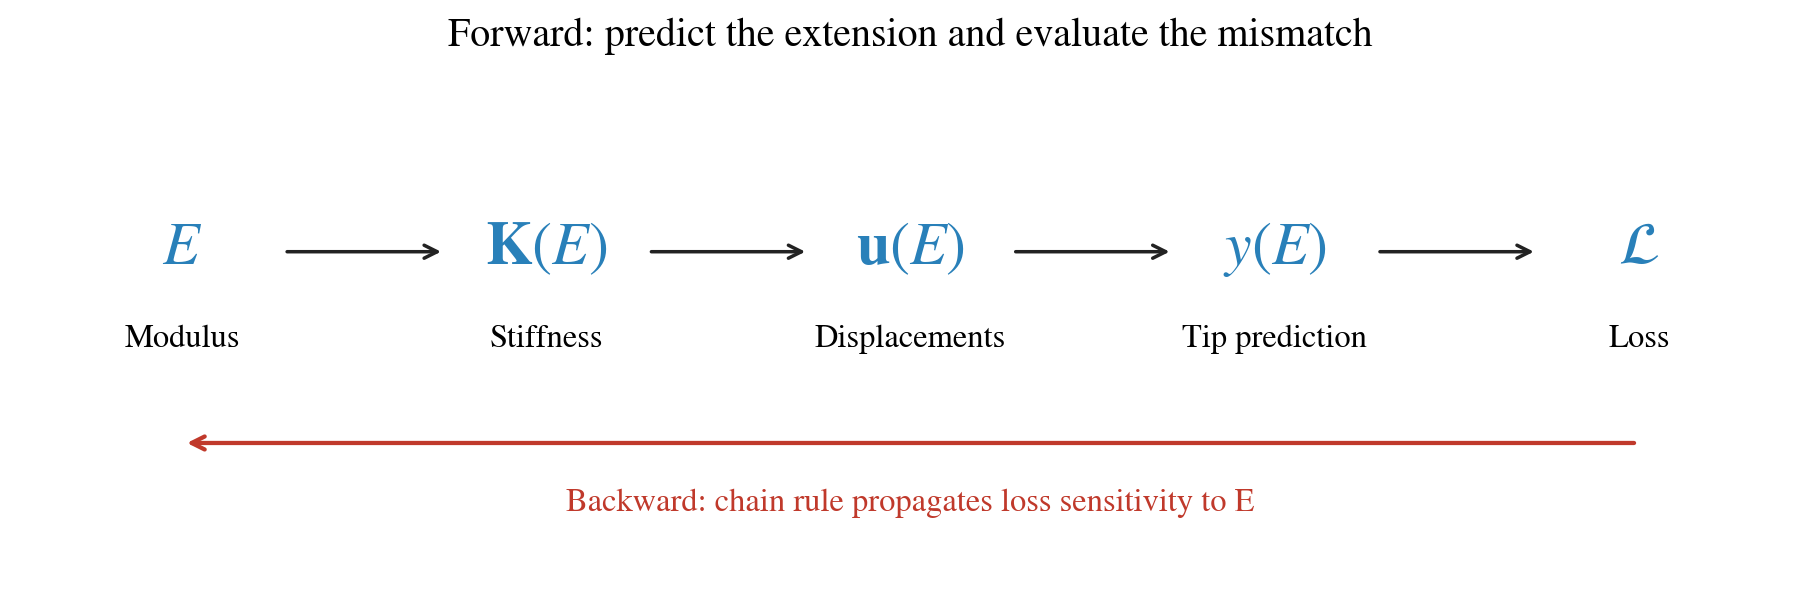

In [16]:
fig, ax = plt.subplots(figsize=(10, 3.2), layout="constrained")
locations = [0, 2, 4, 6, 8]
symbols = [r"$E$", r"$\mathbf{K}(E)$", r"$\mathbf{u}(E)$", r"$y(E)$", r"$\mathcal{L}$"]
labels = ["Modulus", "Stiffness", "Displacements", "Tip prediction", "Loss"]
for pos, symbol, label in zip(locations, symbols, labels):
    ax.text(pos, .75, symbol, ha="center", fontsize=24, color="#2980B9")
    ax.text(pos, .38, label, ha="center", fontsize=13)
for a, b in zip(locations[:-1], locations[1:]):
    ax.annotate("", (b-.55,.8), (a+.55,.8),
                arrowprops={"arrowstyle":"->", "lw":1.4, "color":"#222222"})
ax.annotate("", (0,-.05), (8,-.05),
            arrowprops={"arrowstyle":"->", "lw":1.7, "color":"#C0392B"})
ax.text(4,-.35, "Backward: chain rule propagates loss sensitivity to E",
        ha="center", color="#C0392B")
ax.set(xlim=(-.9,8.9), ylim=(-.65,1.65),
       title="Forward: predict the extension and evaluate the mismatch")
ax.axis("off")
show_figure(fig, "11_autograd_graph")

In [17]:
# requires_grad_(True) tells PyTorch to record every operation that consumes E,
# building the graph. Nothing is differentiated until we ask for a gradient.
E_probe = E_initial.detach().clone().requires_grad_(True)

tip_probe = forward(E_probe).displacement[-1]
loss_probe = loss_from_tip(tip_probe)

# loss_probe is downstream of tip_probe: one shared graph. Retain it on the first
# call, or the second raises "backward through the graph a second time".
dy_dE = torch.autograd.grad(tip_probe, E_probe, retain_graph=True)[0]
dL_dE = torch.autograd.grad(loss_probe, E_probe)[0]

# --- independent hand derivative, valid because this bar has y = FL/EA ---
assert tip_probe.shape == observed.shape == torch.Size([]), \
    "this check assumes a single load case"
expected_dy = -tip_probe.detach() / E_probe.detach()                  # dy/dE = -y/E
expected_dL = 2 * (tip_probe.detach() - observed) / observed.square() * expected_dy

print(f"{'quantity':<10}{'autograd':>17}{'analytical':>17}{'rel. error':>13}   units")
for name, ad, an, unit in (("dy/dE", dy_dE, expected_dy, "mm/MPa"),
                           ("dL/dE", dL_dE, expected_dL, "1/MPa")):
    rel = abs((ad - an) / an).item()
    print(f"{name:<10}{ad.item():>17.8e}{an.item():>17.8e}{rel:>13.1e}   {unit}")

assert torch.allclose(dy_dE, expected_dy, rtol=1e-12, atol=0.0), (
    f"du/dE mismatch: autograd {dy_dE.item():.6e} vs analytical {expected_dy.item():.6e}. "
    "Did the mesh, area or force change since `observed` was recorded?"
)
assert torch.allclose(dL_dE, expected_dL, rtol=1e-12, atol=0.0), (
    f"dL/dE mismatch: autograd {dL_dE.item():.6e} vs analytical {expected_dL.item():.6e}. "
    "Check that loss_from_tip still matches the expression derived above."
)
print("\nPhAST autograd agrees with the analytical derivative to machine precision.")
print("Both are negative: a stiffer bar stretches less, so increasing E reduces the mismatch.")


quantity           autograd       analytical   rel. error   units
dy/dE       -4.00000000e-06  -4.00000000e-06      2.1e-16   mm/MPa
dL/dE       -4.62000000e-05  -4.62000000e-05      1.6e-15   1/MPa

PhAST autograd agrees with the analytical derivative to machine precision.
Both are negative: a stiffer bar stretches less, so increasing E reduces the mismatch.


## 9. Set up a positive modulus and momentum updates
We optimise a dimensionless logarithmic parameter $z$:

$$E=(1\,\mathrm{MPa})e^z,\qquad
\frac{d L}{dz}=E\frac{dL}{dE}.$$

This parameterisation keeps $E$ positive. We use gradient descent with learning rate $\eta=0.1$ and momentum $\beta=0.5$:

$$m_k=\beta m_{k-1}+\frac{d L}{dz}(z_k),\qquad
z_{k+1}=z_k-\eta m_k,\qquad m_{-1}=0.$$

Momentum carries information from previous gradients. It can produce an overshoot followed by diminishing corrections. The plotted oscillations will come from actual solver evaluations.

Stop after the relative tip mismatch is below $10^{-4}$ (0.01%) for **five consecutive evaluations**, with a maximum of 80 updates. The reference modulus is used only for later assessment.

In [18]:
log_E = torch.nn.Parameter(torch.log(E_initial.clone()))
optimizer = torch.optim.SGD([log_E], lr=0.1, momentum=0.5)
relative_tolerance = 1e-4
required_consecutive = 5
max_updates = 80
history, inverse_fields = [], []
consecutive = 0

## 10. Run the inverse loop
Each evaluation uses the **same mesh, support, force and observation**.

1. Solve the bar at the current modulus.
2. Record its displacement and loss.
3. Differentiate the loss with `backward()`.
4. Let the optimiser update the log modulus.

`zero_grad()` clears the previous gradient. `detach()` is used for storing results; the loss used by `backward()` stays connected to the solve.

In [19]:
inverse_start = perf_counter()
for update in range(max_updates + 1):
    optimizer.zero_grad(set_to_none=True)
    E = log_E.exp()
    result = forward(E)
    loss = loss_from_tip(result.displacement[-1])
    history.append([update, E.item(), result.displacement[-1].item(), loss.item()])
    inverse_fields.append(result.displacement.detach().clone())
    consecutive = consecutive + 1 if loss.item() < relative_tolerance**2 else 0
    if consecutive >= required_consecutive or update == max_updates:
        break
    loss.backward()
    optimizer.step()

inverse_seconds = perf_counter() - inverse_start
E_recovered = torch.tensor(history[-1][1])
print(f"Recovered E: {E_recovered.item()/1000:.6f} GPa")
print(f"Updates: {history[-1][0]}; forward evaluations in recovery: {len(history)}")
print(f"Recovery-loop time on this machine: {inverse_seconds:.4f} s")

Recovered E: 209.990865 GPa
Updates: 30; forward evaluations in recovery: 31
Recovery-loop time on this machine: 0.0573 s


## 11. Read the recovery history
The blue curve shows the modulus after each inverse update. The dashed line is the known reference used to generate the synthetic observation.

The red curve shows the same run’s displacement loss on a **logarithmic vertical axis**. Equal vertical distances represent equal factors of reduction. Dips occur when the trial modulus passes close to the correct value.

The oscillations describe successive optimisation estimates at a fixed applied force. Their size and number depend on parameterisation, step size, momentum and the stopping rule.

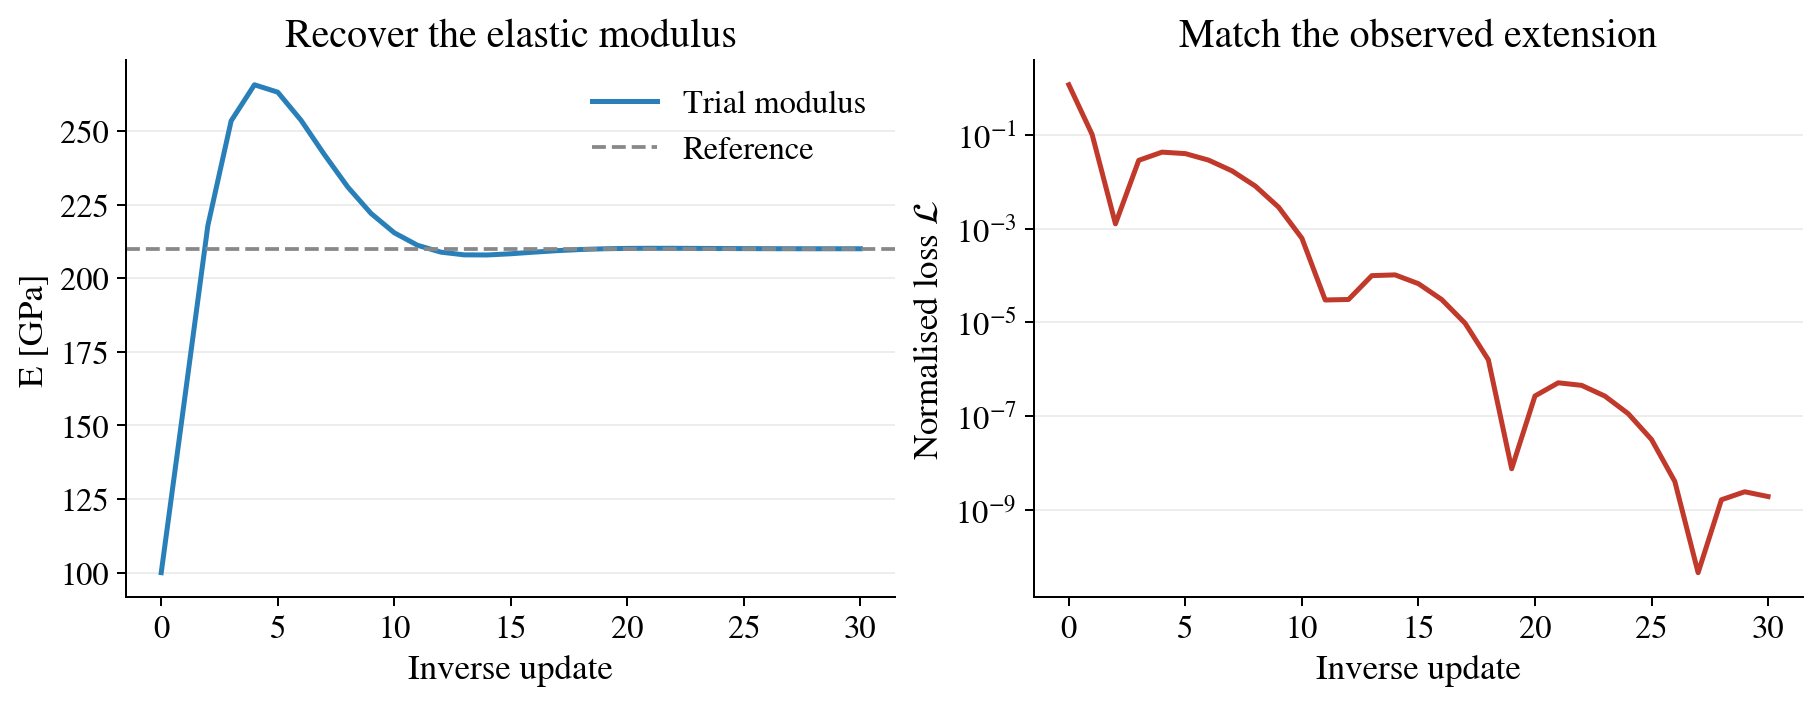

In [20]:
records = np.asarray(history)
iterations, moduli, tips, losses = records.T
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout="constrained")
axes[0].plot(iterations, moduli/1000, color="#2980B9", lw=2, label="Trial modulus")
axes[0].axhline(E_reference.item()/1000, color="#888888", ls="--", label="Reference")
axes[0].set(xlabel="Inverse update", ylabel="E [GPa]", title="Recover the elastic modulus")
axes[0].legend(frameon=False)
axes[1].semilogy(iterations, losses, color="#C0392B", lw=2)
axes[1].set(xlabel="Inverse update", ylabel=r"Normalised loss $\mathcal{L}$",
            title="Match the observed extension")
for ax in axes:
    ax.grid(axis="y", color="#E8E8E8", lw=.6)
show_figure(fig, "06_recovery_history")

### Animate the changing inverse prediction
Each frame displays a recorded displacement field from an inverse evaluation. The applied force is constant. This animation shows how the predicted extension changes as the modulus estimate changes.

The red dot is the **single observation** used in the loss. The grey reference field is shown for interpretation.


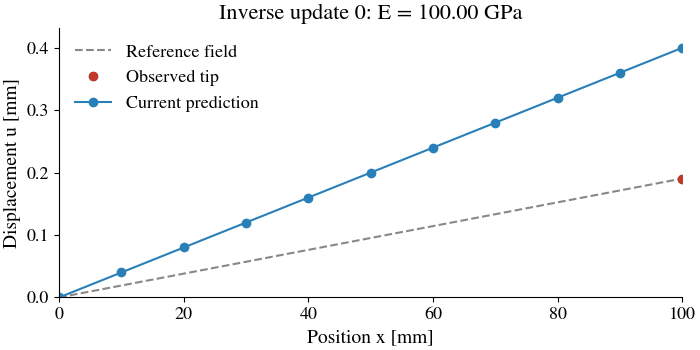

In [21]:
from matplotlib.animation import FuncAnimation, PillowWriter

fields = torch.stack(inverse_fields).numpy()
fig, ax = plt.subplots(figsize=(7, 3.5), layout="constrained")
ax.plot(x, u_reference.numpy(), "--", color="#888888", label="Reference field")
ax.plot([length], [observed.item()], "o", color="#C0392B", label="Observed tip")
line, = ax.plot([], [], "o-", color="#2980B9", label="Current prediction")
ax.set(xlim=(0, length), ylim=(0, fields.max()*1.08),
       xlabel="Position x [mm]", ylabel="Displacement u [mm]")
ax.legend(frameon=False, loc="upper left")
title = ax.set_title("")

def animate(frame):
    line.set_data(x, fields[frame])
    title.set_text(f"Inverse update {int(iterations[frame])}: E = {moduli[frame]/1000:.2f} GPa")
    return line, title

animation = FuncAnimation(fig, animate, frames=len(history), interval=160, blit=False)
animation.save(output / "07_inverse_prediction.gif", writer=PillowWriter(fps=6), dpi=100)
plt.close(fig)
import base64
encoded_gif = base64.b64encode((output / "07_inverse_prediction.gif").read_bytes()).decode("ascii")
display(HTML(f'<img src="data:image/gif;base64,{encoded_gif}" alt="Recorded inverse displacement predictions" style="max-width:100%;width:700px">'))

## 12. Check the recovered solution and save the results
The final check uses the same 4000 N force. The forward reference, initial trial and recovered trial can be compared directly.

For this uniform bar, $E=FL/(A y^{\mathrm{obs}})$ also gives an analytical inverse solution. The purpose of the iterative example is to learn the differentiable-solver workflow, which extends to problems without that closed-form inverse.

The observation is synthetic and noise-free, generated with the same model. With known $L$ and $A$, one nonzero force suffices for one unknown uniform modulus. Autograd supplies the gradients used by the optimisation loop. Comparing recovery methods would require a separate timing study.

In [22]:
recovered = forward(E_recovered)
u_recovered = recovered.displacement.detach()
tip_error = abs(u_recovered[-1].item()/observed.item() - 1)
E_error = abs(E_recovered.item()/E_reference.item() - 1)
assert torch.allclose(u_reference, force*mesh.nodes/(E_reference*area), rtol=1e-10, atol=1e-12)
assert abs(reference.reaction.item() + force) < 1e-6
assert reference.free_residual.abs().max().item() < 1e-6
assert consecutive >= required_consecutive, "Increase the update budget or review optimiser settings."
assert tip_error < relative_tolerance and E_error < 2*relative_tolerance
print(f"Observed / recovered tip: {observed.item():.8f} / {u_recovered[-1].item():.8f} mm")
print(f"Relative modulus error: {100*E_error:.6f}%")
print("All forward, derivative and recovery checks passed.")

Observed / recovered tip: 0.19047619 / 0.19048448 mm
Relative modulus error: 0.004350%
All forward, derivative and recovery checks passed.


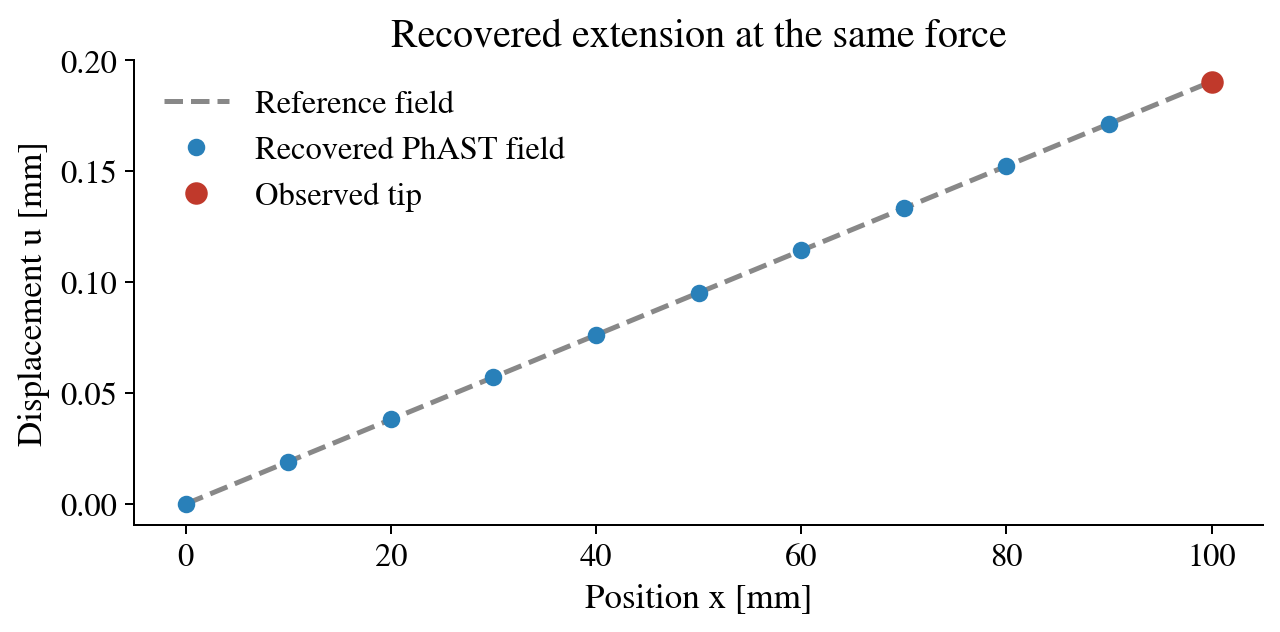

Node    x [mm]     Reference u      Recovered u [mm]
   0       0.0     0.00000000       0.00000000
   1      10.0     0.01904762       0.01904845
   2      20.0     0.03809524       0.03809690
   3      30.0     0.05714286       0.05714534
   4      40.0     0.07619048       0.07619379
   5      50.0     0.09523810       0.09524224
   6      60.0     0.11428571       0.11429069
   7      70.0     0.13333333       0.13333913
   8      80.0     0.15238095       0.15238758
   9      90.0     0.17142857       0.17143603
  10     100.0     0.19047619       0.19048448


In [23]:
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
ax.plot(x, u_reference.numpy(), "--", color="#888888", lw=2, label="Reference field")
ax.plot(x, u_recovered.numpy(), "o", color="#2980B9", label="Recovered PhAST field")
ax.plot([length], [observed.item()], "o", color="#C0392B", ms=8, label="Observed tip")
ax.set(xlabel="Position x [mm]", ylabel="Displacement u [mm]", title="Recovered extension at the same force")
ax.legend(frameon=False)
show_figure(fig, "08_recovered_field")

print("Node    x [mm]     Reference u      Recovered u [mm]")
for i, (xi, ur, uf) in enumerate(zip(x, u_reference, u_recovered)):
    print(f"{i:4d}    {xi:6.1f}     {ur.item():.8f}       {uf.item():.8f}")

In [24]:
with (output / "inverse_history.csv").open("w", newline="") as stream:
    writer = csv.writer(stream)
    writer.writerow(["inverse_update", "E_MPa", "tip_mm", "normalised_loss"])
    writer.writerows(history)
with (output / "recovered_nodes.csv").open("w", newline="") as stream:
    writer = csv.writer(stream)
    writer.writerow(["node", "x_mm", "reference_u_mm", "recovered_u_mm"])
    writer.writerows((i, float(xi), float(ur), float(uf))
                    for i, (xi, ur, uf) in enumerate(zip(x, u_reference, u_recovered)))
summary = {
    "force_N": force, "observation_mm": observed.item(),
    "optimizer": "SGD with momentum", "learning_rate": 0.1, "momentum": 0.5,
    "updates": int(iterations[-1]), "recovery_forward_evaluations": len(history),
    "recovered_E_GPa": E_recovered.item()/1000,
    "relative_E_error": E_error, "relative_tip_error": tip_error,
    "inverse_seconds": inverse_seconds,
    "lesson_seconds_excluding_installation": perf_counter() - lesson_start,
    "phast_revision": "157412953099bfcace1668bb35cb911826a4e95e",
    "checks_passed": True,
}
(output / "results.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("Figures, animation and numerical tables:", output.resolve())

{
  "force_N": 4000.0,
  "observation_mm": 0.19047619047618994,
  "optimizer": "SGD with momentum",
  "learning_rate": 0.1,
  "momentum": 0.5,
  "updates": 30,
  "recovery_forward_evaluations": 31,
  "recovered_E_GPa": 209.99086454579844,
  "relative_E_error": 4.350216286452824e-05,
  "relative_tip_error": 4.350405538677826e-05,
  "inverse_seconds": 0.05730718300037552,
  "lesson_seconds_excluding_installation": 21.660546386000533,
  "phast_revision": "157412953099bfcace1668bb35cb911826a4e95e",
  "checks_passed": true
}
Figures, animation and numerical tables: /content/bar_results


## 13. Interpretation and scope

The inverse calculation reuses the forward solver inside a displacement loss.
PhAST's backward rule supplies the gradient used to update the modulus.

This example recovers one uniform modulus from one synthetic, noise-free tip
observation, with geometry and load known. Additional unknowns or measurement
noise can require more observations, regularisation and uncertainty analysis.


## Exercises

1. **Change the starting guess** to 500 GPa. Compare the optimisation history and final displacement mismatch with the original run.
2. **Compare optimisers.** Try SGD and Adam at learning rates `0.3` and `0.005`. Record the iterations and final relative displacement mismatch. As an extension, adapt the loop to LBFGS using its required closure.
3. **Add measurement noise.** After recording the scalar observation, replace it with `observed + 0.002 * observed.abs() * torch.randn_like(observed)`. Rerun the inverse calculation and compare the recovered modulus with the noise-free result.
4. **Recover two unknowns.** Make both $E$ and $A$ trainable. Use $u(L)=FL/(EA)$ to explain why this observation identifies their product. Compare the pairs recovered from different initial guesses.
